In [1]:
import torch
from torch import nn
import numpy as np

In [2]:
from pathlib import Path
data_path = Path("data/")
image_path = data_path / "desert101"

In [3]:
image_path

WindowsPath('data/desert101')

In [4]:
import os

In [5]:
def check_data(dir_path):

    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"# of directories: {len(dirnames)} and {len(filenames)} image in {dirpath}")

In [6]:
check_data(image_path)

# of directories: 2 and 1 image in data\desert101
# of directories: 4 and 1 image in data\desert101\test
# of directories: 0 and 20 image in data\desert101\test\baklava
# of directories: 0 and 20 image in data\desert101\test\cannoli
# of directories: 0 and 20 image in data\desert101\test\cup_cakes
# of directories: 0 and 20 image in data\desert101\test\donuts
# of directories: 4 and 1 image in data\desert101\train
# of directories: 0 and 80 image in data\desert101\train\baklava
# of directories: 0 and 80 image in data\desert101\train\cannoli
# of directories: 0 and 80 image in data\desert101\train\cup_cakes
# of directories: 0 and 80 image in data\desert101\train\donuts


In [7]:
train_dir = image_path / "train"
test_dir = image_path / "test"

In [8]:
train_dir

WindowsPath('data/desert101/train')

In [9]:
test_dir

WindowsPath('data/desert101/test')

In [10]:
from PIL import Image
import random

In [11]:


image_path_list = list(image_path.glob("*/*/*.jpg"))

random_image = random.choice(image_path_list)

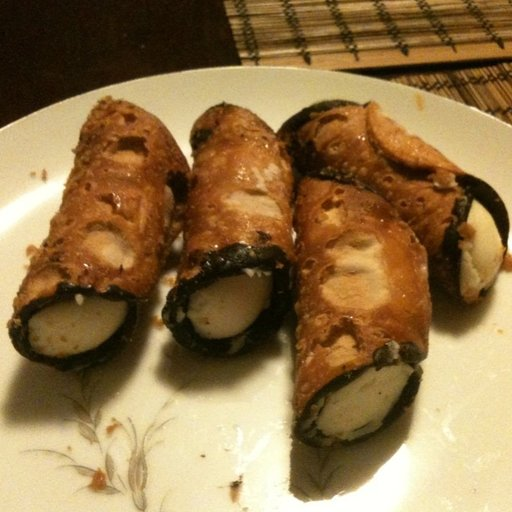

In [12]:
Image.open(random_image)

In [13]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [14]:
data_transform = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.2),
    transforms.RandomHorizontalFlip(p=0.4),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.TrivialAugmentWide(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4500, 0.3887, 0.3314], std=[0.3109, 0.2937, 0.2855])

]
)

In [15]:
train_data = datasets.ImageFolder(root=train_dir,
                                  transform=data_transform,
                                  target_transform=None)

test_data = datasets.ImageFolder(root=test_dir,
                                 transform=data_transform)

In [16]:
train_data

Dataset ImageFolder
    Number of datapoints: 316
    Root location: data\desert101\train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomApply(
               p=0.2
               GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 2.0))
           )
               RandomHorizontalFlip(p=0.4)
               RandomVerticalFlip(p=0.2)
               TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
               ToTensor()
               Normalize(mean=[0.45, 0.3887, 0.3314], std=[0.3109, 0.2937, 0.2855])
           )

In [17]:
test_data

Dataset ImageFolder
    Number of datapoints: 77
    Root location: data\desert101\test
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomApply(
               p=0.2
               GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 2.0))
           )
               RandomHorizontalFlip(p=0.4)
               RandomVerticalFlip(p=0.2)
               TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
               ToTensor()
               Normalize(mean=[0.45, 0.3887, 0.3314], std=[0.3109, 0.2937, 0.2855])
           )

In [18]:
class_names = train_data.classes

In [19]:
len(train_data), len(test_data)

(316, 77)

In [20]:
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

In [21]:
NUM_WORKERS

12

In [22]:
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              num_workers=NUM_WORKERS,
                              shuffle=True)

test_dataloader = DataLoader(dataset=test_data,
                             batch_size=BATCH_SIZE,
                             num_workers=NUM_WORKERS,
                             shuffle=False)

In [23]:
train_dataloader.dataset[0][0]

tensor([[[-1.4474, -1.4474, -1.4474,  ...,  0.8861,  0.7221,  0.5834],
         [-1.4474, -1.4474, -1.4474,  ...,  0.7095,  0.4951,  0.3437],
         [-1.4474, -1.4474, -1.4474,  ...,  0.3185,  0.1419,  0.0158],
         ...,
         [-1.4474, -1.4474, -1.4474,  ...,  1.2141,  1.1384,  1.0753],
         [-1.4474, -1.4474, -1.4474,  ...,  1.2393,  1.1888,  1.1762],
         [-1.4474, -1.4474, -1.4474,  ...,  1.2645,  1.2645,  1.2267]],

        [[-1.3235, -1.3235, -1.3235,  ...,  0.7862,  0.5859,  0.4657],
         [-1.3235, -1.3235, -1.3235,  ...,  0.6126,  0.3189,  0.1720],
         [-1.3235, -1.3235, -1.3235,  ...,  0.1319, -0.1218, -0.3220],
         ...,
         [-1.3235, -1.3235, -1.3235,  ...,  0.5459,  0.4791,  0.4390],
         [-1.3235, -1.3235, -1.3235,  ...,  0.6393,  0.6260,  0.5993],
         [-1.3235, -1.3235, -1.3235,  ...,  0.7328,  0.7328,  0.6660]],

        [[-1.1608, -1.1608, -1.1608,  ..., -0.0619, -0.2954, -0.3641],
         [-1.1608, -1.1608, -1.1608,  ..., -0

In [24]:
class DesertClassifier(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()

        self.conv_block_1 = nn.Sequential(
            
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3,
                      padding=1,
                      stride=1),
            nn.ReLU(),

            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      padding=1,
                      stride=1),
             nn.ReLU(),     

             nn.MaxPool2d(kernel_size=2,
                          stride=2))

        self.conv_block_2 = nn.Sequential(

            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      padding=1,
                      stride=1),
            nn.ReLU(),

            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      padding=1,
                      stride=1),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2,
                         stride=2))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units * 16 * 16,
                      out_features=output_shape))


    def forward(self, x):
        return self.classifier(self.conv_block_2(self.conv_block_1(x)))

In [25]:
model_0 = DesertClassifier(input_shape=3,
                           hidden_units=64,
                           output_shape=len(class_names))

In [26]:
model_0

DesertClassifier(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16384, out_features=4, bias=True)
  )
)

In [27]:
from torchinfo import summary

In [28]:
summary(model_0, input_size=[1,3,64,64])

Layer (type:depth-idx)                   Output Shape              Param #
DesertClassifier                         [1, 4]                    --
├─Sequential: 1-1                        [1, 64, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 64, 64, 64]           1,792
│    └─ReLU: 2-2                         [1, 64, 64, 64]           --
│    └─Conv2d: 2-3                       [1, 64, 64, 64]           36,928
│    └─ReLU: 2-4                         [1, 64, 64, 64]           --
│    └─MaxPool2d: 2-5                    [1, 64, 32, 32]           --
├─Sequential: 1-2                        [1, 64, 16, 16]           --
│    └─Conv2d: 2-6                       [1, 64, 32, 32]           36,928
│    └─ReLU: 2-7                         [1, 64, 32, 32]           --
│    └─Conv2d: 2-8                       [1, 64, 32, 32]           36,928
│    └─ReLU: 2-9                         [1, 64, 32, 32]           --
│    └─MaxPool2d: 2-10                   [1, 64, 16, 16]           --


In [29]:
def train_step(model: torch.nn.Module, dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module, optimizer: torch.optim.Optimizer):

    model.train()

    train_loss = 0
    train_acc = 0

    for batch, (X, y) in enumerate(dataloader):

        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y_pred_class)

    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    
    return train_loss, train_acc

In [30]:
def test_step(model: torch.nn.Module, dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):

    model.eval()

    test_loss = 0
    test_acc = 0

    with torch.inference_mode():

        for batch, (X, y) in enumerate(dataloader):

            test_pred_logits = model(X)
            loss = loss_fn(test_pred_logits, y)
            
            test_loss += loss.item()

            test_pred_labels = test_pred_logits.argmax(dim=1)

            test_acc += (test_pred_labels == y).sum().item() / len(test_pred_labels)

    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc 

In [31]:
def train(model: torch.nn.Module, 
          train_dataloader: torch.utils.data.DataLoader, 
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 20):

    results = {"train_loss" : [],
               "train_acc" : [],
               "test_loss" : [],
               "test_acc" : []}

    for epoch in range(epochs):
        
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer)

        test_loss, test_acc = test_step(model=model,
                                        dataloader=test_dataloader,
                                        loss_fn=loss_fn)

        print(f"Epoch: {epoch}, Train Loss: {train_loss}, Train Acc: {train_acc}, Test Loss: {test_loss}, Test Acc: {test_acc}")

        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    return results       

In [32]:
EPOCHS = 20
model_0 = DesertClassifier(input_shape=3,
                           hidden_units=32,
                           output_shape=len(class_names))
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.001)

model_0_results = train(model=model_0,
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        loss_fn=loss_fn,
                        optimizer=optimizer,
                        epochs=EPOCHS)

Epoch: 0, Train Loss: 1.3969384551048278, Train Acc: 0.23348214285714283, Test Loss: 1.3799657424290974, Test Acc: 0.19791666666666666
Epoch: 1, Train Loss: 1.3855517745018004, Train Acc: 0.27232142857142855, Test Loss: 1.3841008345286052, Test Acc: 0.25
Epoch: 2, Train Loss: 1.3739416360855103, Train Acc: 0.2986607142857143, Test Loss: 1.421107570330302, Test Acc: 0.2604166666666667
Epoch: 3, Train Loss: 1.3556820392608642, Train Acc: 0.34151785714285715, Test Loss: 1.3833746512730916, Test Acc: 0.2692307692307692
Epoch: 4, Train Loss: 1.3348618626594544, Train Acc: 0.359375, Test Loss: 1.4049695332845051, Test Acc: 0.2916666666666667
Epoch: 5, Train Loss: 1.3150882005691529, Train Acc: 0.3763392857142857, Test Loss: 1.358249584833781, Test Acc: 0.3020833333333333
Epoch: 6, Train Loss: 1.2764790296554565, Train Acc: 0.4267857142857143, Test Loss: 1.3736393451690674, Test Acc: 0.3173076923076923
Epoch: 7, Train Loss: 1.2969441771507264, Train Acc: 0.39285714285714285, Test Loss: 1.2906

In [33]:
model_0_results

{'train_loss': [1.3969384551048278,
  1.3855517745018004,
  1.3739416360855103,
  1.3556820392608642,
  1.3348618626594544,
  1.3150882005691529,
  1.2764790296554565,
  1.2969441771507264,
  1.2710651993751525,
  1.2790282011032104,
  1.1993521213531495,
  1.2347318172454833,
  1.1657224237918853,
  1.2195040166378022,
  1.1623360753059386,
  1.174615454673767,
  1.169282352924347,
  1.1312888026237489,
  1.1020691633224486,
  1.0916100859642028],
 'train_acc': [0.23348214285714283,
  0.27232142857142855,
  0.2986607142857143,
  0.34151785714285715,
  0.359375,
  0.3763392857142857,
  0.4267857142857143,
  0.39285714285714285,
  0.43080357142857145,
  0.39375,
  0.4584821428571429,
  0.45,
  0.4866071428571429,
  0.4504464285714286,
  0.4924107142857143,
  0.5223214285714286,
  0.5017857142857143,
  0.5089285714285714,
  0.5254464285714285,
  0.546875],
 'test_loss': [1.3799657424290974,
  1.3841008345286052,
  1.421107570330302,
  1.3833746512730916,
  1.4049695332845051,
  1.3582495

In [34]:
import matplotlib.pyplot as plt

In [35]:
def plot_loss_curves(results):
    loss = results["train_loss"]
    test_loss = results["test_loss"]
    accuracy = results["train_acc"]
    test_accuracy = results["test_acc"]

    epochs = range(len(results["train_loss"]))

    plt.figure(figsize = (16,8))

    plt.subplot(1,2,1)
    plt.plot(epochs, loss, label="train_loss")
    plt.plot(epochs, test_loss, label="test_loss")
    plt.title("loss")
    plt.xlabel("Epochs")
    plt.legend()
    
    plt.subplot(1,2,2)
    plt.plot(epochs, accuracy, label="train_accuracy")
    plt.plot(epochs, test_accuracy, label="test_accuracy")
    plt.title("accuracy")
    plt.xlabel("epochs")
    plt.legend()

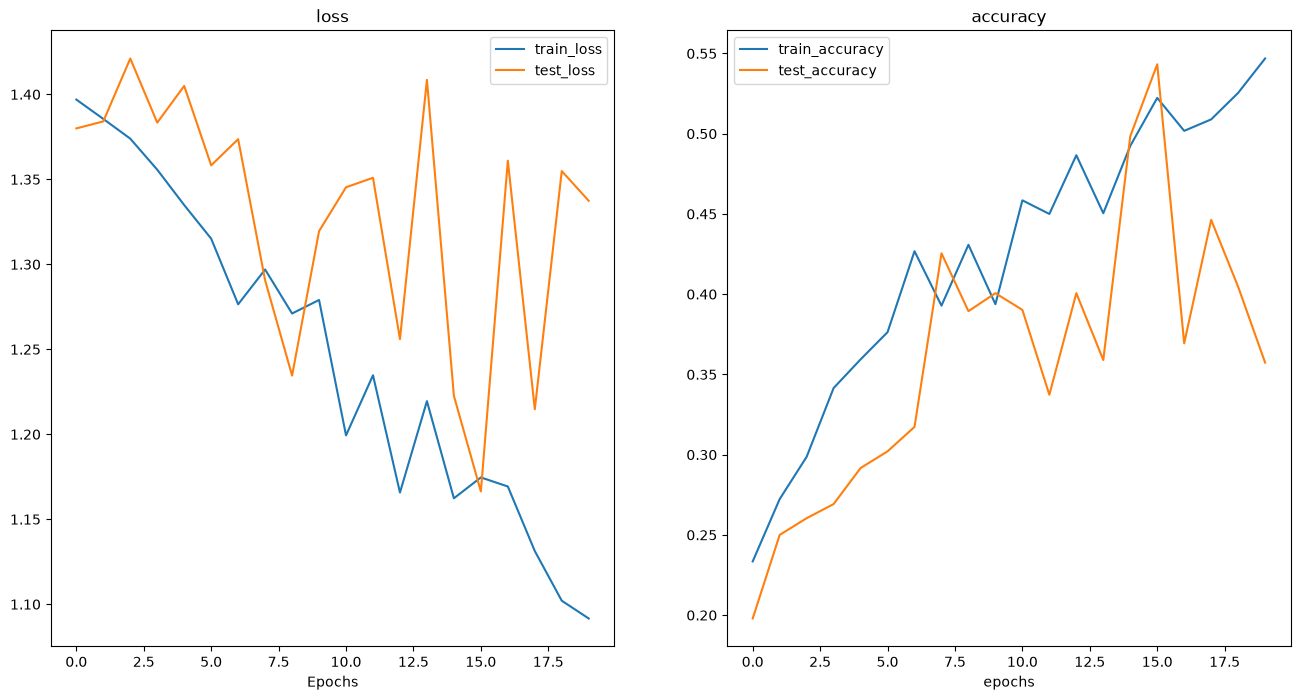

In [36]:
plot_loss_curves(model_0_results)

In [37]:
online_image_path = data_path / "baklavaresmi.jpg"

In [38]:
online_image_path

WindowsPath('data/baklavaresmi.jpg')

In [39]:
import torchvision

In [40]:
single_image = torchvision.io.read_image(str(online_image_path))

In [41]:
single_image

tensor([[[227, 226, 225,  ..., 223, 223, 223],
         [225, 224, 223,  ..., 223, 223, 223],
         [224, 223, 222,  ..., 223, 223, 223],
         ...,
         [206, 223, 226,  ..., 225, 213, 215],
         [195, 219, 230,  ..., 213, 195, 203],
         [207, 221, 221,  ..., 231, 211, 219]],

        [[218, 217, 216,  ..., 214, 214, 214],
         [216, 215, 214,  ..., 214, 214, 214],
         [215, 214, 213,  ..., 214, 214, 214],
         ...,
         [199, 216, 219,  ..., 218, 206, 208],
         [188, 212, 223,  ..., 201, 183, 192],
         [200, 214, 214,  ..., 218, 198, 206]],

        [[203, 202, 201,  ..., 197, 197, 197],
         [201, 200, 199,  ..., 197, 197, 197],
         [200, 199, 198,  ..., 197, 197, 197],
         ...,
         [193, 210, 213,  ..., 202, 190, 190],
         [182, 206, 217,  ..., 185, 167, 174],
         [194, 208, 208,  ..., 202, 181, 189]]], dtype=torch.uint8)

In [42]:
single_image = torchvision.io.read_image(str(online_image_path)).type(torch.float32)

In [43]:
single_image

tensor([[[227., 226., 225.,  ..., 223., 223., 223.],
         [225., 224., 223.,  ..., 223., 223., 223.],
         [224., 223., 222.,  ..., 223., 223., 223.],
         ...,
         [206., 223., 226.,  ..., 225., 213., 215.],
         [195., 219., 230.,  ..., 213., 195., 203.],
         [207., 221., 221.,  ..., 231., 211., 219.]],

        [[218., 217., 216.,  ..., 214., 214., 214.],
         [216., 215., 214.,  ..., 214., 214., 214.],
         [215., 214., 213.,  ..., 214., 214., 214.],
         ...,
         [199., 216., 219.,  ..., 218., 206., 208.],
         [188., 212., 223.,  ..., 201., 183., 192.],
         [200., 214., 214.,  ..., 218., 198., 206.]],

        [[203., 202., 201.,  ..., 197., 197., 197.],
         [201., 200., 199.,  ..., 197., 197., 197.],
         [200., 199., 198.,  ..., 197., 197., 197.],
         ...,
         [193., 210., 213.,  ..., 202., 190., 190.],
         [182., 206., 217.,  ..., 185., 167., 174.],
         [194., 208., 208.,  ..., 202., 181., 189.]]]

In [44]:
single_image = single_image / 255

In [45]:
single_image

tensor([[[0.8902, 0.8863, 0.8824,  ..., 0.8745, 0.8745, 0.8745],
         [0.8824, 0.8784, 0.8745,  ..., 0.8745, 0.8745, 0.8745],
         [0.8784, 0.8745, 0.8706,  ..., 0.8745, 0.8745, 0.8745],
         ...,
         [0.8078, 0.8745, 0.8863,  ..., 0.8824, 0.8353, 0.8431],
         [0.7647, 0.8588, 0.9020,  ..., 0.8353, 0.7647, 0.7961],
         [0.8118, 0.8667, 0.8667,  ..., 0.9059, 0.8275, 0.8588]],

        [[0.8549, 0.8510, 0.8471,  ..., 0.8392, 0.8392, 0.8392],
         [0.8471, 0.8431, 0.8392,  ..., 0.8392, 0.8392, 0.8392],
         [0.8431, 0.8392, 0.8353,  ..., 0.8392, 0.8392, 0.8392],
         ...,
         [0.7804, 0.8471, 0.8588,  ..., 0.8549, 0.8078, 0.8157],
         [0.7373, 0.8314, 0.8745,  ..., 0.7882, 0.7176, 0.7529],
         [0.7843, 0.8392, 0.8392,  ..., 0.8549, 0.7765, 0.8078]],

        [[0.7961, 0.7922, 0.7882,  ..., 0.7725, 0.7725, 0.7725],
         [0.7882, 0.7843, 0.7804,  ..., 0.7725, 0.7725, 0.7725],
         [0.7843, 0.7804, 0.7765,  ..., 0.7725, 0.7725, 0.

In [46]:
single_image.shape

torch.Size([3, 592, 592])

Text(0.5, 1.0, 'torch.Size([3, 592, 592])')

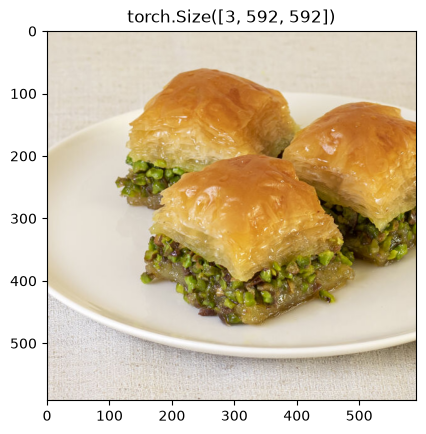

In [47]:
plt.imshow(single_image.permute(1,2,0))
plt.title(single_image.shape)

In [48]:
single_image_transform = transforms.Compose(
    [
        transforms.Resize(size=(64,64))
    ]
)

single_image = single_image_transform(single_image)

In [49]:
single_image.shape

torch.Size([3, 64, 64])

Text(0.5, 1.0, 'torch.Size([3, 64, 64])')

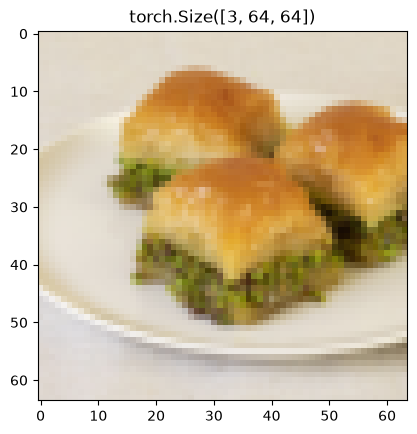

In [50]:
plt.imshow(single_image.permute(1,2,0))
plt.title(single_image.shape)

In [51]:
single_image.unsqueeze(dim=0).shape

torch.Size([1, 3, 64, 64])

In [52]:
single_image = single_image.unsqueeze(dim=0)

In [53]:
model_0.eval()
with torch.inference_mode():
    logits = model_0(single_image)
    probs = torch.softmax(logits, dim=1)
    pred_idx = probs.argmax(dim=1).item()
    
print("Predicted class: ", class_names[pred_idx])   

Predicted class:  baklava


In [54]:
def compute_mean_std(dataloader: DataLoader):
    """
    dataloader, ToTensor() sonrası [0,1] aralığında tensor döndürmeli.
    Augmentasyon transformlarını (flip, rotation, TrivialAugmentWide vs.) içermemeli.
    """
    channels_sum = torch.zeros(3)
    channels_sq_sum = torch.zeros(3)
    n_pixels = 0

    for images, _ in dataloader:  # images: [B, 3, H, W]
        b, c, h, w = images.shape
        images = images.view(b, c, -1)
        channels_sum += images.sum(dim=[0, 2])
        channels_sq_sum += (images ** 2).sum(dim=[0, 2])
        n_pixels += b * h * w

    mean = channels_sum / n_pixels
    std = torch.sqrt(channels_sq_sum / n_pixels - mean ** 2)

    return mean, std